# Breast Cancer Prediction Model

Dataset: https://www.kaggle.com/datasets/remyz5/curated-healthcare-and-genomics-datasets?utm_source=chatgpt.com


In [5]:
import pandas as pd
import numpy as np

In [22]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

data = pd.read_csv("/content/drive/MyDrive/colabDatasets/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape:", data.shape)
print(data.head())

Mounted at /content/drive
Shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfacti

In [23]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [24]:
data = data.drop([
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
], axis=1)

In [20]:
data.fillna(data.mean(), inplace=True)

In [25]:
data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})

In [29]:
data = pd.get_dummies(data, drop_first=True)

data.head(3)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True


In [30]:
X = data.drop("Attrition", axis=1)
y = data["Attrition"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8775510204081632


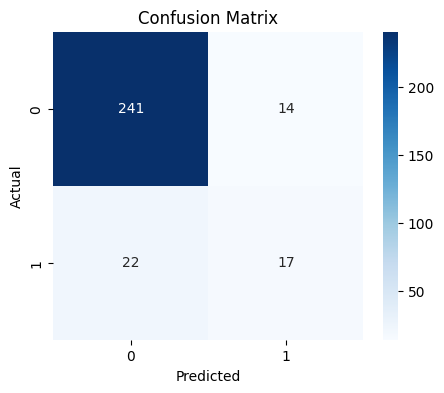

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_score(y_test, y_pred)

0.8775510204081632

In [40]:
precision_score(y_test, y_pred)

0.5483870967741935

In [41]:
recall_score(y_test, y_pred)

0.4358974358974359

In [42]:
f1_score(y_test, y_pred)

0.4857142857142857

In [43]:
y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.7902463549522373)

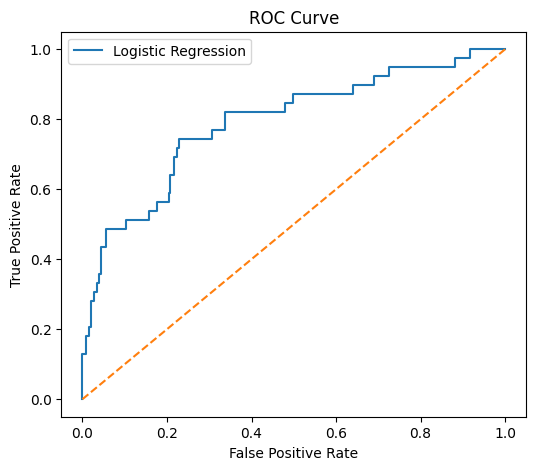

In [45]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.55      0.44      0.49        39

    accuracy                           0.88       294
   macro avg       0.73      0.69      0.71       294
weighted avg       0.87      0.88      0.87       294



In [17]:
model.predict_proba(X_test[:5])

array([[1.13590250e-01, 8.86409750e-01],
       [9.99990991e-01, 9.00936206e-06],
       [9.96920905e-01, 3.07909541e-03],
       [5.10134225e-04, 9.99489866e-01],
       [6.06389713e-05, 9.99939361e-01]])

In [46]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability (Class 1)": y_prob
})

results.head(10)

,Actual,Predicted,Probability (Class 1)
0,0,0,0.064918
1,0,0,0.002636
2,1,0,0.342612
3,0,0,0.012852
4,0,0,0.050677
5,0,0,0.327484
6,0,0,0.404279
7,0,0,0.034446
8,0,0,0.060535
9,0,0,0.013796


In [47]:
results.sample(10)

,Actual,Predicted,Probability (Class 1)
197,0,0,0.066601
125,1,1,0.521460
77,0,0,0.100871
80,0,0,0.000203
43,0,0,0.046448
23,0,0,0.386464
235,0,0,0.005850
176,0,0,0.076720
174,0,0,0.037452
129,0,0,0.124932
